In [1]:
import os 
import requests
import numpy as np
import pandas as pd 
from collections import defaultdict

#for Web scraper 
import selenium
import twilio
import pybettor 

#for kaggle data
import kaggle
import tempfile
from io import StringIO

#read in R file 
import pyreadr

#ml models
import xgboost  
import lightgbm 

#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#data handling
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import MinMaxScaler


#plotting
import seaborn as sns
import matplotlib.pyplot as plt

#deep learning 
# import keras
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LeakyReLU, ReLU
#sklearn models 
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score


Sports Betting: nerual networks and portfolio theory, kelly criterion info 
- https://arxiv.org/abs/2307.13807?utm_source=chatgpt.com

UFC Markov Chain Fight Prediction:
- https://livrepository.liverpool.ac.uk/3166169/

Web Scraping and Kelly Criterion EV 
- https://github.com/jacksebastian17/betting-algo?utm_source=chatgpt.com

ML for NBA stratedgy 
- https://github.com/kyleskom/NBA-Machine-Learning-Sports-Betting

Sports odds history with csv files
- https://www.sportsoddshistory.com/?utm_source=chatgpt.com

Survey of Current Research 
- https://arxiv.org/pdf/2410.21484
- Calibration over accuracy, does the distribution of predicted outcomes match real world 
    - https://en.wikipedia.org/wiki/Brier_score

Reinforcement Based Approach
- https://ieeexplore.ieee.org/document/9969987?utm_source=chatgpt.com

Elo Rating Model 
- https://arxiv.org/pdf/1802.00527

Live UFC Betting Strategy
- https://arxiv.org/pdf/2312.11067


Data Sets to start off with 
NBA
-https://www.kaggle.com/datasets/pablote/nba-enhanced-stats
-https://www.kaggle.com/datasets/ehallmar/nba-historical-stats-and-betting-data?utm_source=chatgpt.com\

NFL
-https://www.kaggle.com/datasets/tobycrabtree/nfl-scores-and-betting-data?utm_source=chatgpt.com

Soccer
-https://www.kaggle.com/datasets/austro/beat-the-bookie-worldwide-football-dataset?utm_source=chatgpt.com
https://www.kaggle.com/datasets/eladsil/football-games-odds?utm_source=chatgpt.com

UFC
-https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset?utm_source=chatgpt.com
        - github repo: 
        - https://github.com/shortlikeafox/tiger-millionaire/wiki
- updated csv of aggregated kaggle ufc stats 
    -https://www.kaggle.com/datasets/aaronfriasr/ufc-fighters-statistics




In [2]:
#ufc aggregated library
#github for up to date data from this kaggle: https://github.com/shortlikeafox/ultimate_ufc_dataset

def get_dataset(dataset_name):
    files = kaggle.api.dataset_list_files(dataset_name).files
    csv_file = files[0].name

    csv_data = kaggle.api.dataset_download_file(dataset_name, csv_file, quiet=False)
    with tempfile.TemporaryDirectory() as temp_dir:
        kaggle.api.dataset_download_files(dataset_name, path=temp_dir, unzip=True)
        
        # Construct full file path
        csv_path = os.path.join(temp_dir, csv_file)
        
        # Load the CSV file into Pandas DataFrame
        df = pd.read_csv(csv_path)

    return df
    
dataset = "mdabbert/ultimate-ufc-dataset"
ufc = get_dataset(dataset) 
ufc = ufc.sort_values(by="Date", ascending=True).reset_index(drop=True)


Dataset URL: https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset
ufc-master.csv: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset


In [3]:
ufc.columns

Index(['RedFighter', 'BlueFighter', 'RedOdds', 'BlueOdds', 'RedExpectedValue',
       'BlueExpectedValue', 'Date', 'Location', 'Country', 'Winner',
       ...
       'FinishDetails', 'FinishRound', 'FinishRoundTime', 'TotalFightTimeSecs',
       'RedDecOdds', 'BlueDecOdds', 'RSubOdds', 'BSubOdds', 'RKOOdds',
       'BKOOdds'],
      dtype='object', length=118)

In [17]:
ufc[['RedOdds','Finish', 'RedExpectedValue']]

,RedOdds,Finish,RedExpectedValue
0,140.0,U-DEC,140.0000
1,215.0,KO/TKO,215.0000
2,-250.0,KO/TKO,40.0000
3,-345.0,KO/TKO,28.9855
4,-120.0,KO/TKO,83.3333
...,...,...,...
6523,-130.0,SUB,76.9231
6524,700.0,SUB,700.0000
6525,-550.0,KO/TKO,18.1818
6526,-238.0,U-DEC,42.0168


In [ ]:
(140) / 100

In [ ]:
def get_ufc_master(path):
    response = requests.get(path)
    if response.status_code == 200:
        df = pd.read_csv(StringIO(response.text))
        print("CSV file loaded successfully!")
        print(df.head())  
        return df
    else:
        print("Failed to download file.")
        
master_path = 'https://raw.githubusercontent.com/shortlikeafox/ultimate_ufc_dataset/refs/heads/main/ufc-master.csv' 
upcoming_path = 'https://raw.githubusercontent.com/shortlikeafox/ultimate_ufc_dataset/refs/heads/main/upcoming.csv'

ufc = get_ufc_master(master_path)
ufc_upcoming = get_ufc_master(upcoming_path)

ufc = ufc.sort_values(by="Date", ascending=True).reset_index(drop=True)


In [ ]:
#- https://tamaszilagyi.com/ufc.stats/ 

rda_file = r'C:\Users\jcmar\OneDrive\Vscode files\Sports_Betting\ufc_stats.rda'
result = pyreadr.read_r(rda_file)
# Extract the loaded objects (it returns a dictionary)
for key in result.keys():
    print(f"Object name: {key}")
    data = result[key]  # This is usually a pandas DataFrame
    print(data.head()) 

df = result['ufc_stats']
df.info()

df = df.sort_values(by="fight_date", ascending=True).reset_index(drop=True)

df['fighter']

In [7]:
def elo_rating(df,k):
    elo_dic = defaultdict(list)
    red_elo = []
    blue_elo = []
    for _, row in df.iterrows(): 
        red_name = row['RedFighter']
        blue_name = row['BlueFighter']
        if red_name not in elo_dic:
            elo_dic[red_name] = [1500]
        if blue_name not in elo_dic:
            elo_dic[blue_name] = [1500]
        if row['Winner'] == 'Red':
            prev_blue = elo_dic[blue_name][-1] #elo pre fight
            prev_red = elo_dic[red_name][-1]
            red_elo.append(prev_red)
            blue_elo.append(prev_blue)

            d = prev_red - prev_blue
            mu = 1 / (1 + 10**(-d/400))
            red_new = prev_red + k * (1-mu) #red wins

            d = prev_blue - prev_red
            mu = 1 / (1 + 10**(-d/400))
            blue_new = prev_blue + k * (0-mu) #blue loses
            
            elo_dic[red_name].append(red_new)
            elo_dic[blue_name].append(blue_new)

        if row['Winner'] == 'Blue':
            prev_blue = elo_dic[blue_name][-1]
            prev_red = elo_dic[red_name][-1]
            red_elo.append(prev_red)
            blue_elo.append(prev_blue)

            d = prev_blue - prev_red
            mu = 1 / (1 + 10**(-d/400))
            blue_new = prev_blue + k * (1-mu) #blue wins

            d = prev_red - prev_blue
            mu = 1 / (1 + 10**(-d/400))
            red_new = prev_red + k * (0-mu) #red loses
            
            elo_dic[red_name].append(red_new)
            elo_dic[blue_name].append(blue_new)

    return elo_dic, red_elo, blue_elo

elo_dic, red_elo,blue_elo = elo_rating(ufc, 25)
ufc['red_elo'] = red_elo
ufc['blue_elo'] = blue_elo

In [9]:
def mma_math(df):
    fighter_dic_wins = defaultdict(set)  # Use sets for faster lookup
    fighter_dic_losses = defaultdict(set)

    mma_math_red = []
    mma_math_blue = []

    for idx, row in df.iterrows(): 
        red_fighter = row['RedFighter']
        blue_fighter = row['BlueFighter']

        # Slice the dataframe to get all previous rows before the current row
        previous_fights = df.iloc[:idx]

        # Get the most recent fight where red_fighter or blue_fighter appeared as red
        red_history = previous_fights[
            (previous_fights['RedFighter'] == red_fighter) | 
            (previous_fights['BlueFighter'] == red_fighter)
        ].tail(1)  # Ensures a DataFrame is returned

        # Get the most recent fight where blue_fighter appeared as either red or blue
        blue_history = previous_fights[
            (previous_fights['RedFighter'] == blue_fighter) | 
            (previous_fights['BlueFighter'] == blue_fighter)
        ].tail(1)

        if not red_history.empty:
            red_history = red_history.iloc[0]  # Convert to Series
            if red_history['RedFighter'] == red_fighter and red_history['Winner'] == 'Red':
                fighter_dic_wins[red_fighter].add(red_history['BlueFighter'])

            if red_history['BlueFighter'] == red_fighter and red_history['Winner'] == 'Blue':
                fighter_dic_wins[red_fighter].add(red_history['RedFighter'])

            # Red fighter's opponents lost to
            if red_history['RedFighter'] == red_fighter and red_history['Winner'] == 'Blue':
                fighter_dic_losses[red_fighter].add(red_history['BlueFighter'])
            
            if red_history['BlueFighter'] == red_fighter and red_history['Winner'] == 'Red':
                fighter_dic_losses[red_fighter].add(red_history['RedFighter'])

        if not blue_history.empty:
            blue_history = blue_history.iloc[0]
            # Get blue fighter's defeated opponents
            if blue_history['RedFighter'] == blue_fighter and blue_history['Winner'] == 'Red':
                
                fighter_dic_wins[blue_fighter].add(blue_history['BlueFighter'])

            if blue_history['BlueFighter'] == blue_fighter and blue_history['Winner'] == 'Blue':
                fighter_dic_wins[blue_fighter].add(blue_history['RedFighter'])

            # Blue fighter's opponents lost to
            if blue_history['RedFighter'] == blue_fighter and blue_history['Winner'] == 'Blue':
                fighter_dic_losses[blue_fighter].add(blue_history['BlueFighter'])
            
            if blue_history['BlueFighter'] == blue_fighter and blue_history['Winner'] == 'Red':
                fighter_dic_losses[blue_fighter].add(blue_history['RedFighter'])

        # Assign 1 if the red fighter has previously defeated the blue fighter, else 0
        common_opponents_red = fighter_dic_wins[red_fighter] & fighter_dic_losses[blue_fighter]
        mma_math_red.append(1 if common_opponents_red else 0)

        # Check if there exists a fighter that blue beat and red lost to
        common_opponents_blue = fighter_dic_wins[blue_fighter] & fighter_dic_losses[red_fighter]
        mma_math_blue.append(1 if common_opponents_blue else 0)
    return fighter_dic_wins, mma_math_red, mma_math_blue


dic_wins, math_red, math_blue = mma_math(ufc)

ufc['math_red'] = math_red
ufc['math_blue'] = math_blue

In [34]:
np.unique(ufc['math_red'], return_counts=True)

(array([0, 1]), array([6308,  220]))

In [15]:
#Predict Red or Blue winner with odds
#X_train.info()

ufc["ID"] = np.arange(len(ufc))

le = LabelEncoder()

selected_features = ["Winner",
    'RedOdds', 'BlueOdds', 'RedLosses', 'BlueLosses', 'BlueLongestWinStreak', 'RedLongestWinStreak', 'Gender', 
    'KODif', 'SubDif', 'HeightDif', 'ReachDif', 'RedExpectedValue', 'BlueExpectedValue', 
    'BlueCurrentLoseStreak', 'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded', 'BlueAvgSigStrPct', 
    'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct', 
    'BlueTotalRoundsFought', 'BlueTotalTitleBouts', 'BlueWinsByDecisionMajority', 'BlueWinsByDecisionSplit', 
    'BlueWinsByDecisionUnanimous', 'BlueWinsByKO', 'BlueWinsBySubmission', 'BlueWinsByTKODoctorStoppage', 
    'BlueWins', 'BlueHeightCms', 'BlueReachCms', 'BlueWeightLbs', 
    'RedCurrentLoseStreak', 'RedCurrentWinStreak', 'RedDraws', 'RedAvgSigStrLanded', 'RedAvgSigStrPct', 
    'RedAvgSubAtt', 'RedAvgTDLanded', 'RedAvgTDPct',
    'RedTotalRoundsFought', 'RedTotalTitleBouts', 'RedWinsByDecisionMajority', 'RedWinsByDecisionSplit', 
    'RedWinsByDecisionUnanimous', 'RedWinsByKO', 'RedWinsBySubmission', 'RedWinsByTKODoctorStoppage','AvgTDDif','SigStrDif','AgeDif','AvgSubAttDif','LoseStreakDif',
    'LongestWinStreakDif','TotalRoundDif', 'RedAge','BlueAge','NumberOfRounds','WinDif','LossDif','TotalTitleBoutDif', 'WeightClass','BetterRank','RedStance','BlueStance',
    'Country', 'WinStreakDif', 'Location','red_elo','blue_elo','BPFPRank', 'RPFPRank','math_red','math_blue',
    'Date',"RedFighter",'BlueFighter'
]

model_dat = ufc[selected_features]

model_dat['BPFPRank'] = model_dat['BPFPRank'].fillna(0)
model_dat['RPFPRank'] = model_dat['RPFPRank'].fillna(0)

#Filling in missing data decreased model accuracy 
# model_dat['BlueAvgTDLanded'] = model_dat['BlueAvgTDLanded'].fillna(0)
# model_dat['RedAvgTDLanded'] = model_dat['RedAvgTDLanded'].fillna(0)
# model_dat['BlueAvgSigStrLanded'] = model_dat['BlueAvgSigStrLanded'].fillna(0)
# model_dat['RedAvgSigStrLanded'] = model_dat['RedAvgSigStrLanded'].fillna(0)
# model_dat['BlueAvgSubAtt'] = model_dat['BlueAvgSubAtt'].fillna(0)
# model_dat['RedAvgSubAtt'] = model_dat['RedAvgSubAtt'].fillna(0)
# model_dat['BlueAvgTDPct'] = model_dat['BlueAvgTDPct'].fillna(0)
# model_dat['RedAvgTDPct'] = model_dat['RedAvgTDPct'].fillna(0)
# model_dat['RedAvgSigStrPct'] = model_dat['RedAvgSigStrPct'].fillna(0)
# model_dat['BlueAvgSigStrPct'] = model_dat['BlueAvgSigStrPct'].fillna(0)

model_dat['elo_diff'] = model_dat['red_elo'] - model_dat['blue_elo']

model_dat['BetterRank'] = model_dat['BetterRank'].map({"Blue":0,"Red":1,"neither":2}).astype(int)
model_dat['Gender'] = model_dat["Gender"].map({"MALE":1,"FEMALE":0}).astype(int)
model_dat["Winner"] = model_dat['Winner'].map({'Red':1,"Blue":0}).astype(int)

#helps with model accuracy 
cat_cols = model_dat.select_dtypes(include=['object', 'category']).columns.tolist()
num_categorical = model_dat.select_dtypes(include=['object']).shape[1]
print(f"Number of categorical columns: {num_categorical}")
numerical_cols = model_dat.columns.difference(cat_cols)
mm_scaler = MinMaxScaler()
model_dat[numerical_cols] = mm_scaler.fit_transform(model_dat[numerical_cols])

#issues with label encoder causing changes to model accuracy 
# model_dat['FinishDetails'] = le.fit_transform(model_dat['FinishDetails'])
# model_dat['Finish'] = le.fit_transform(model_dat['Finish'])
model_dat['WeightClass'] = le.fit_transform(model_dat['WeightClass'])

model_dat['RedStance'] = le.fit_transform(model_dat['RedStance'])
model_dat['BlueStance'] = le.fit_transform(model_dat['BlueStance'])
model_dat['Country'] = le.fit_transform(model_dat['Country'])
model_dat['Location'] = le.fit_transform(model_dat['Location'])

# cols_to_encode = ['FinishDetails', 'Finish', 'WeightClass', 'BetterRank', 'RedStance', 'BlueStance', 'Country', 'Location']
# model_dat = pd.get_dummies(model_dat, columns=cols_to_encode, drop_first=True).reset_index(drop=True)

nulls = model_dat.isnull().sum().to_frame("Null Count")
print(nulls)

train_size = int(len(ufc)*0.85)

train_dat = model_dat[:train_size].reset_index(drop=True)
train_dat = train_dat.drop(columns=['Date',"RedFighter",'BlueFighter'])
train_dat = train_dat.dropna(axis=0)

test_dat = model_dat[train_size:].reset_index(drop=True)

test_dat = test_dat.dropna(axis=0)

X_train = train_dat.drop(columns=["Winner"])
y_train = train_dat['Winner']
X_test = test_dat.drop(columns=["Winner","Date","RedFighter",'BlueFighter'])
y_test = test_dat["Winner"]

engineered_features = ['elo_diff']

Number of categorical columns: 8
             Null Count
Winner                0
RedOdds             227
BlueOdds            226
RedLosses             0
BlueLosses            0
...                 ...
math_blue             0
Date                  0
RedFighter            0
BlueFighter           0
elo_diff              0

[80 rows x 1 columns]


C:\Users\jcmar\AppData\Local\Temp\ipykernel_41556\1812893059.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_dat['BPFPRank'] = model_dat['BPFPRank'].fillna(0)
C:\Users\jcmar\AppData\Local\Temp\ipykernel_41556\1812893059.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_dat['RPFPRank'] = model_dat['RPFPRank'].fillna(0)
C:\Users\jcmar\AppData\Local\Temp\ipykernel_41556\1812893059.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

Accuracy: 0.6723


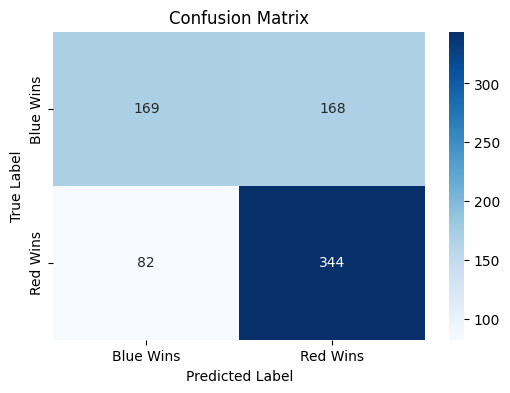

In [136]:
model = LogisticRegression(max_iter=4000, C=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.6723


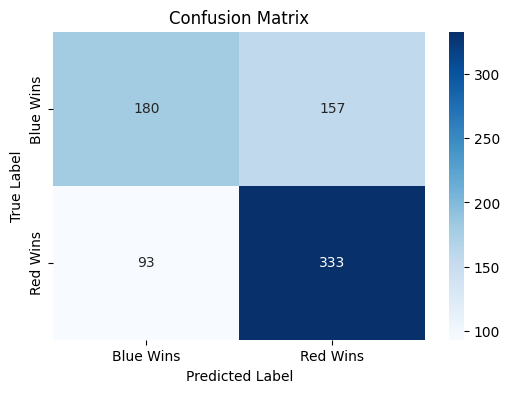

In [137]:
params = {
    'objective': 'binary',  # Binary classification
    'metric': 'binary_error',  # Error rate
    'boosting_type': 'gbdt',
    'n_estimators': 600,
    'learning_rate': 0.05,
    'min_data_in_leaf': 5,
    'num_leaves': 60,
    'max_depth': -1,
    'verbose': -1
}

train_data = lightgbm.Dataset(X_train, label=y_train)
test_data = lightgbm.Dataset(X_test, label=y_test, reference=train_data)
lgb = lightgbm.train(params, train_data, num_boost_round=100, valid_sets=[test_data])

y_pred_prob = lgb.predict(X_test)  # Get probabilities
y_pred = np.round(y_pred_prob)  # Convert to binary predictions

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


301, 167

In [ ]:
def build_model(input_size):
    model = Sequential([
        Dense(128, input_dim=input_size),
        BatchNormalization(),
        ReLU(),
        Dropout(0.2),

        Dense(256),
        BatchNormalization(),
        ReLU(),
        Dropout(0.2),
        
        Dense(128),
        BatchNormalization(),
        ReLU(),
        Dropout(0.2),

        Dense(64),
        ReLU(),

        Dense(1, activation='sigmoid')  # Output layer
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Create the model
input_size = X_train.shape[1]  # Example feature size
model = build_model(input_size)

# Print model summary
history = model.fit(X_train, y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.show()


0.7233960814444871
Accuracy: 0.6867627785058977
Train Accuracy: 0.9317877842175658
Brier Score Before Calibration: 0.2009376871247208
Brier Score After Calibration: 0.20022843286350245
ROC-AUC Before Calibration: 0.7567044203897968
ROC-AUC After Calibration: 0.7679260528552123


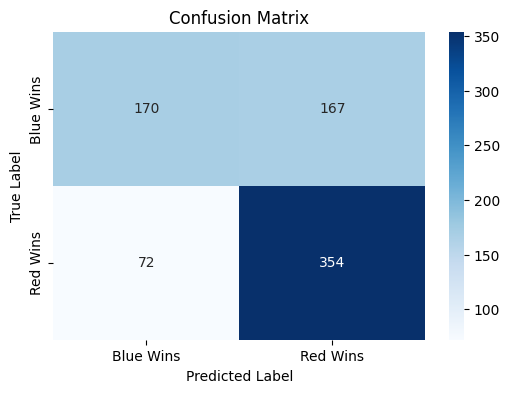

              precision    recall  f1-score   support

         0.0       0.70      0.50      0.59       337
         1.0       0.68      0.83      0.75       426

    accuracy                           0.69       763
   macro avg       0.69      0.67      0.67       763
weighted avg       0.69      0.69      0.68       763



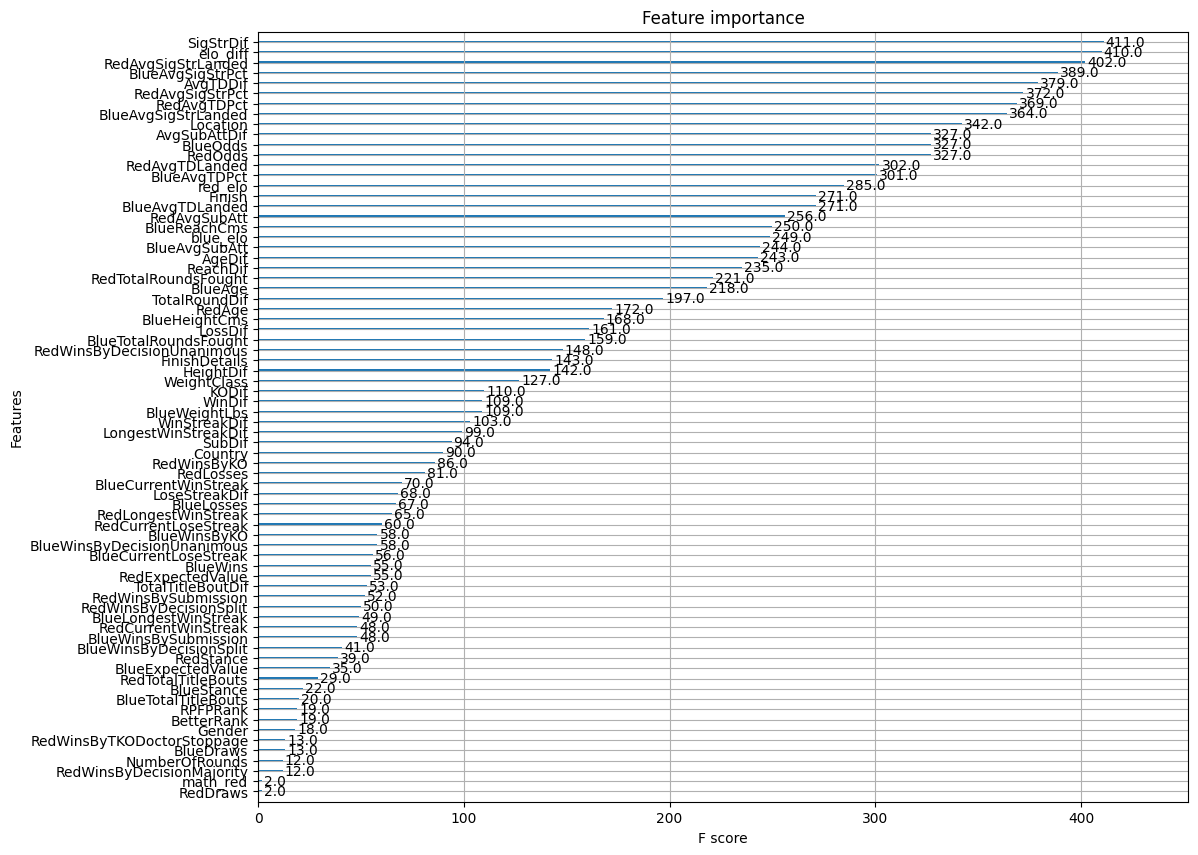

In [6]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(scale_pos_weight)

xgb = xgboost.XGBClassifier(
    objective="binary:logistic", 
    eval_metric="auc",  
    n_estimators = 800,
    max_depth=8,
    learning_rate=.03,
    min_child_weight=2,
    reg_alpha=2,
    reg_lambda=2,
    gamma=1, # pruning 
    grow_policy='lossguide'
)

X_train = np.array(X_train)
X_test = np.array(X_test)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy}')
y_pred_train = xgb.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Train Accuracy: {train_accuracy}")

calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid', cv=8)  # 'sigmoid' = Platt scaling, 'isotonic' = Isotonic regression
calibrated_xgb.fit(X_train, y_train)

# Get predicted probabilities before and after calibration
prob_before = xgb.predict_proba(X_test)[:, 1]
prob_after = calibrated_xgb.predict_proba(X_test)[:, 1]

# Evaluate probability calibration
print("Brier Score Before Calibration:", brier_score_loss(y_test, prob_before))
print("Brier Score After Calibration:", brier_score_loss(y_test, prob_after))
print("ROC-AUC Before Calibration:", roc_auc_score(y_test, prob_before))
print("ROC-AUC After Calibration:", roc_auc_score(y_test, prob_after))


probability_scores2 = xgb.predict_proba(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))

drop_columns = ('Winner','Date','RedFighter','BlueFighter')
column_names = [c for c in selected_features+engineered_features if c not in drop_columns]
xgb.get_booster().feature_names = column_names
fig, ax = plt.subplots(figsize=(12, 10))  # Force width=12, height=10
xgboost.plot_importance(xgb, ax=ax)  
plt.show()

0.7233960814444871
Accuracy: 0.6788990825688074
Train Accuracy: 0.7151136870263041


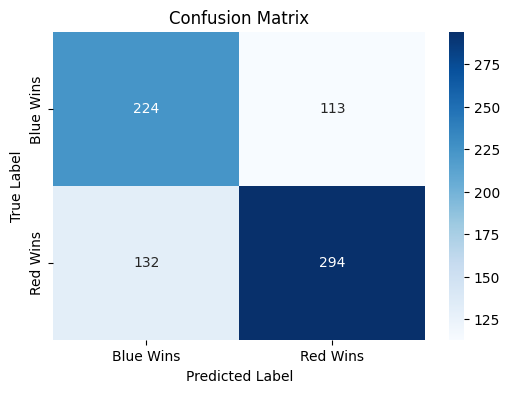

              precision    recall  f1-score   support

         0.0       0.63      0.66      0.65       337
         1.0       0.72      0.69      0.71       426

    accuracy                           0.68       763
   macro avg       0.68      0.68      0.68       763
weighted avg       0.68      0.68      0.68       763



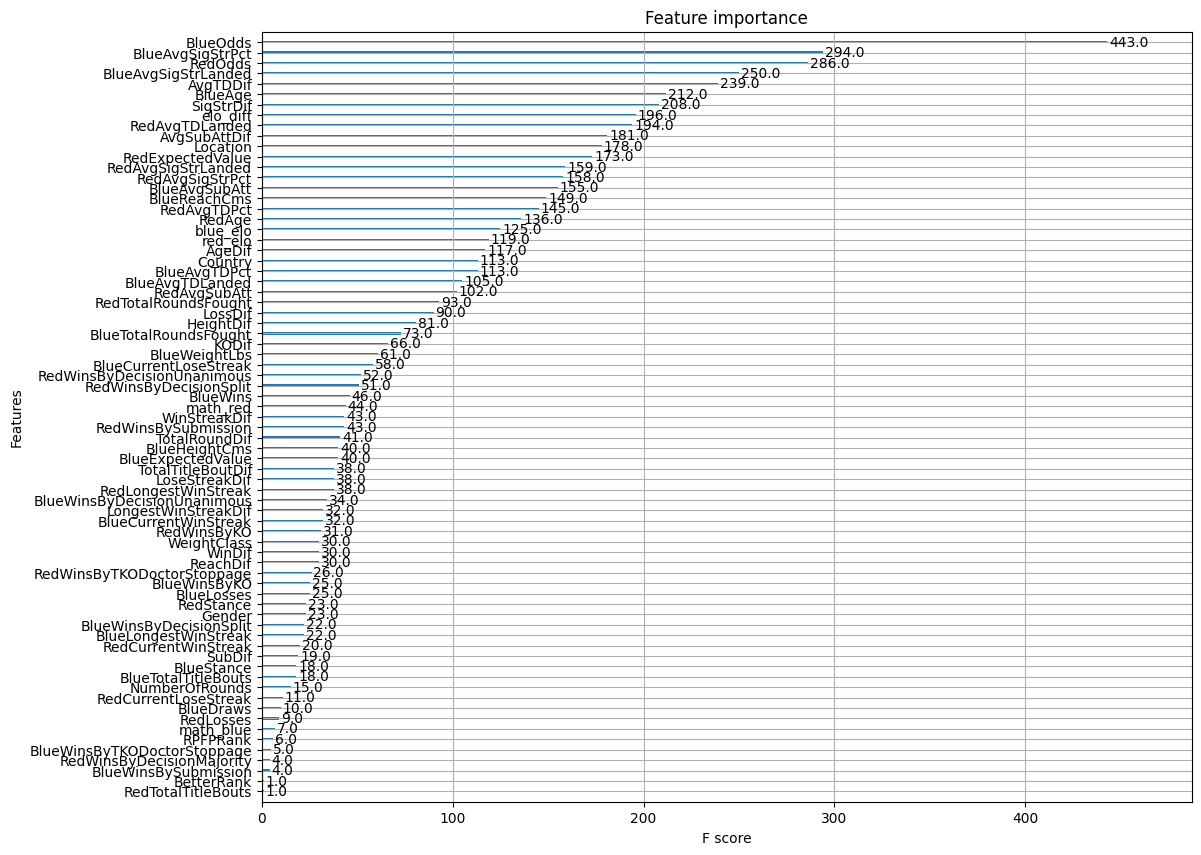

Brier Score Before Calibration: 0.20338435868206142
Brier Score After Calibration: 0.201972451044253
ROC-AUC Before Calibration: 0.7534375391816777
ROC-AUC After Calibration: 0.7568924924422897


In [16]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(scale_pos_weight)
xgb = xgboost.XGBClassifier(
    objective="binary:logistic", 
    eval_metric="auc",  
    n_estimators = 1500,
    max_depth=7,
    learning_rate=.01,
    min_child_weight=3,
    reg_alpha=6,
    reg_lambda=2,
    gamma=2, # pruning 
    grow_policy='lossguide',
    # colsample_bytree =.8,
    # subsample = .8,
    scale_pos_weight=scale_pos_weight 
)
X_train = np.array(X_train)
X_test = np.array(X_test)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy}')

y_pred_train = xgb.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Train Accuracy: {train_accuracy}")
# xgboost.plot_importance(xgb)
probability_scores1 = xgb.predict_proba(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))
drop_columns = ('Winner','Date','RedFighter','BlueFighter')
column_names = [c for c in selected_features+engineered_features if c not in drop_columns]
xgb.get_booster().feature_names = column_names
fig, ax = plt.subplots(figsize=(12, 10))  # Force width=12, height=10
xgboost.plot_importance(xgb, ax=ax)  
plt.show()

calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid', cv=8)  # 'sigmoid' = Platt scaling, 'isotonic' = Isotonic regression
calibrated_xgb.fit(X_train, y_train)

# Get predicted probabilities before and after calibration
prob_before = xgb.predict_proba(X_test)[:, 1]
prob_after1 = calibrated_xgb.predict_proba(X_test)[:, 1]

# Evaluate probability calibration
print("Brier Score Before Calibration:", brier_score_loss(y_test, prob_before))
print("Brier Score After Calibration:", brier_score_loss(y_test, prob_after1))
print("ROC-AUC Before Calibration:", roc_auc_score(y_test, prob_before))
print("ROC-AUC After Calibration:", roc_auc_score(y_test, prob_after1))

In [ ]:
probability_scores1

Brier Score: 0.19785415301223985
ROC-AUC  0.7648472436995861
              precision    recall  f1-score   support

         0.0       0.70      0.59      0.64       337
         1.0       0.71      0.80      0.75       426

    accuracy                           0.71       763
   macro avg       0.70      0.69      0.70       763
weighted avg       0.71      0.71      0.70       763



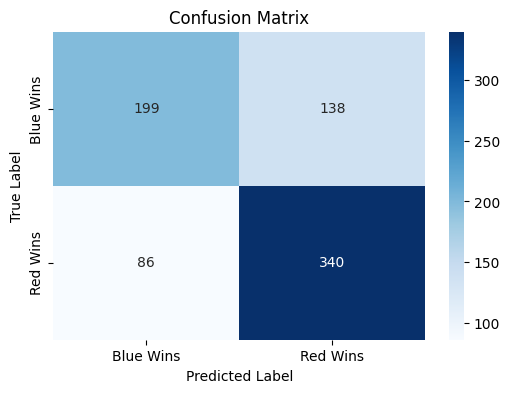

In [200]:
ensemble_preds = (probability_scores1 + probability_scores2) / 2

# Convert to binary labels (Threshold at 0.5)
ensemble_labels = (ensemble_preds >= 0.5).astype(int)
y_final = [0 if row[0] == 1 else 1 for row in ensemble_labels]
print("Brier Score:", brier_score_loss(y_test, ensemble_preds[:,1]))
print("ROC-AUC ", roc_auc_score(y_test, ensemble_preds[:,1]))

# y_final = [0 if prob == 1 else 1 for prob in ensemble_labels]
# print("Brier Score:", brier_score_loss(y_test, ensemble_preds))
# print("ROC-AUC ", roc_auc_score(y_test, ensemble_preds))
print(classification_report(y_test, y_final))
cm = confusion_matrix(y_test, y_final)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

         0.0       0.70      0.60      0.65       337
         1.0       0.72      0.80      0.76       426

    accuracy                           0.71       763
   macro avg       0.71      0.70      0.70       763
weighted avg       0.71      0.71      0.71       763



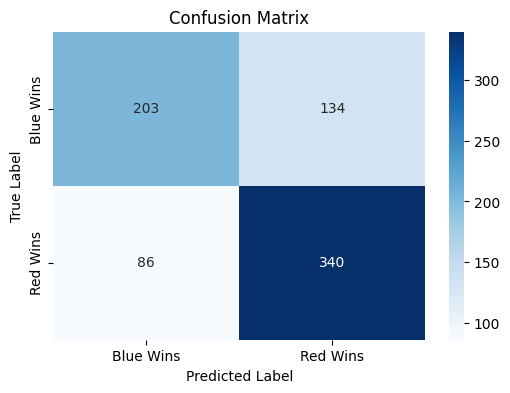

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

meta_X = np.column_stack((probability_scores1, probability_scores2))
meta_model = LogisticRegression()
meta_model.fit(meta_X, y_test)
meta_preds = meta_model.predict(meta_X)
meta_probs = meta_model.predict_proba(meta_X)

print(classification_report(y_test, meta_preds))
cm = confusion_matrix(y_test, meta_preds)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

C:\Users\jcmar\AppData\Local\Temp\ipykernel_13668\2107033773.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticks(), rotation=90)


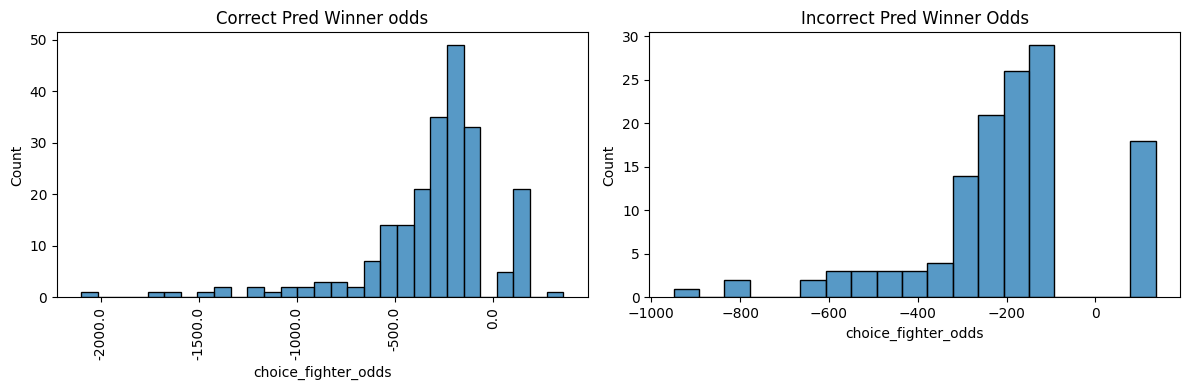

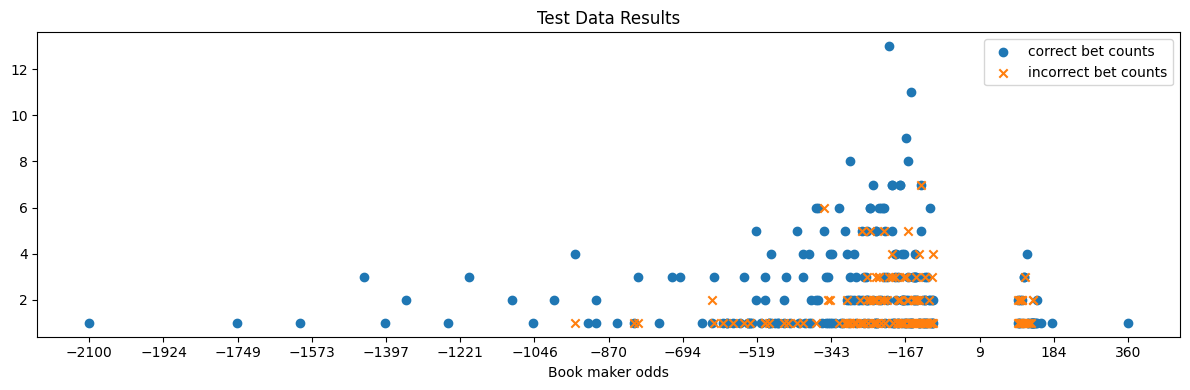

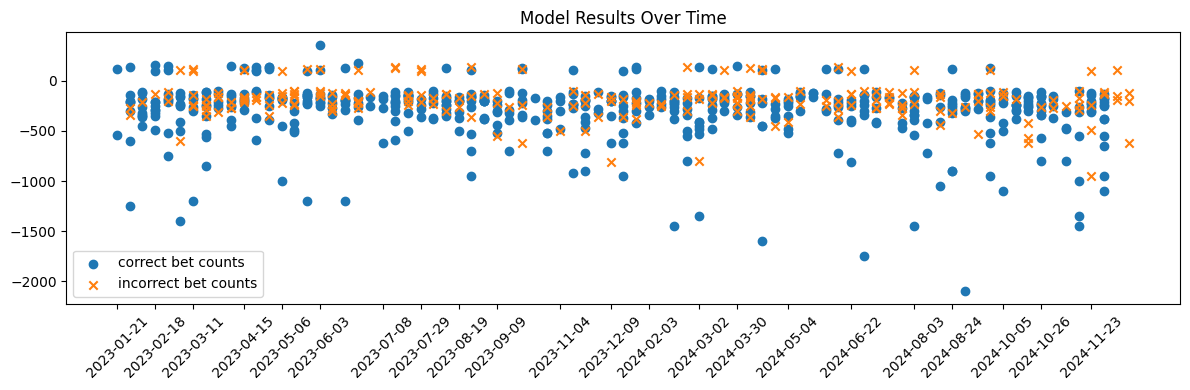

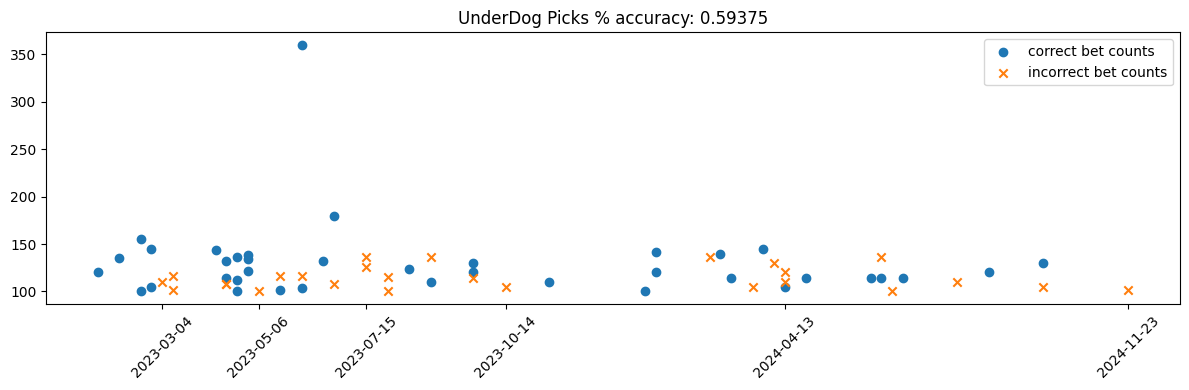

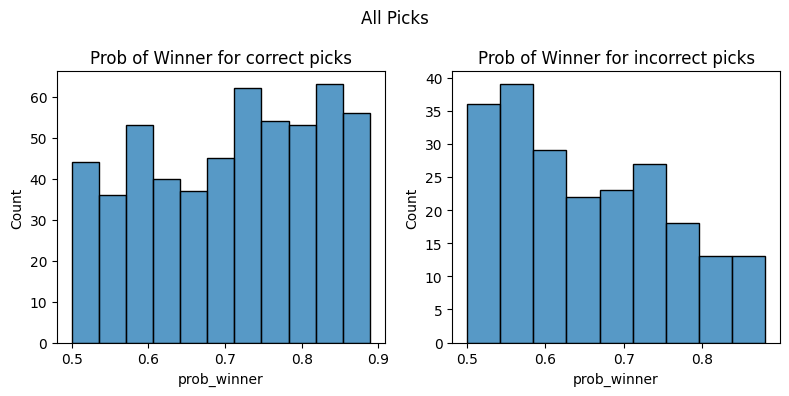

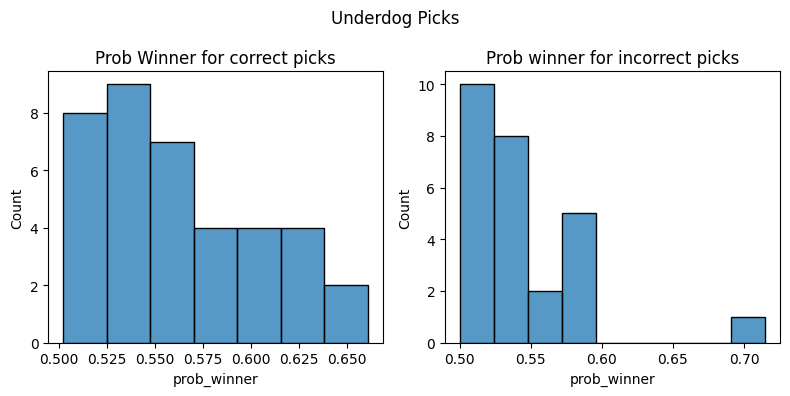

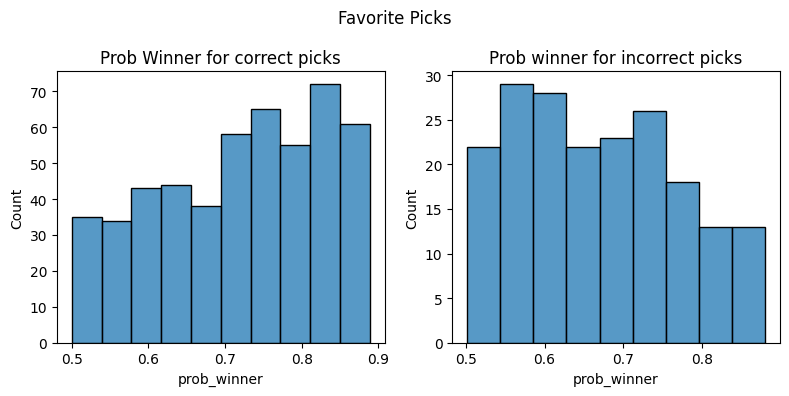

In [9]:
df_results = test_dat.copy()
df_results[numerical_cols] = mm_scaler.inverse_transform(df_results[numerical_cols])   # Reverse the min max scaler for plotting 

# df_results['prob_blue_winner'] = probability_scores1[:,0]
# df_results['prob_red_winner'] = probability_scores1[:,1]
# df_results['pred_winner'] = y_pred

#stacked results
df_results['prob_blue_winner'] = meta_probs[:,0]
df_results['prob_red_winner'] = meta_probs[:,1]
df_results['pred_winner'] = meta_preds

df_results['prob_winner'] = df_results[['prob_blue_winner','prob_red_winner']].max(axis=1)
df_results['winner_odds'] = np.where(df_results['Winner'] == 1, df_results['RedOdds'], df_results['BlueOdds'])
df_results['correct_pred_winner'] = (df_results['pred_winner'] == df_results['Winner']).astype(int)
df_results['choice_fighter_odds'] = np.where(df_results['pred_winner'] == 1, df_results['RedOdds'], df_results['BlueOdds'])

# Filter correct predictions
df_correct_pred = df_results[df_results["correct_pred_winner"] == 1].copy() 
df_incorrect_pred = df_results[df_results["correct_pred_winner"] == 0].copy()

pred_correct_odds = df_results[df_results["correct_pred_winner"] == 1]['choice_fighter_odds'].value_counts().sort_index()
pred_incorrect_odds = df_results[df_results["correct_pred_winner"] == 0]['choice_fighter_odds'].value_counts().sort_index()

#correct results over time 


# Plot the data
fig, axes = plt.subplots(1,2,figsize=(12, 4))
sns.histplot(pred_correct_odds.index, ax=axes[0])
# axes[0].set_xticks(np.linspace(min(pred_correct_odds.index), max(pred_correct_odds.index), num=15))
axes[0].set_xticklabels(axes[0].get_xticks(), rotation=90)
axes[0].set_title("Correct Pred Winner odds")
sns.histplot(pred_incorrect_odds.index, ax=axes[1])
axes[1].set_title("Incorrect Pred Winner Odds")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,4))
plt.scatter(pred_correct_odds.index, pred_correct_odds.values, marker='o', label='correct bet counts')
plt.scatter(pred_incorrect_odds.index, pred_incorrect_odds.values, marker='x', label='incorrect bet counts')
plt.xlabel("Book maker odds")
plt.xticks(np.linspace(min(pred_correct_odds.index), max(pred_correct_odds.index), num=15))
plt.title("Test Data Results")
plt.legend()
plt.tight_layout()
plt.show()

#Model Results Over time 
plt.figure(figsize=(12,4))
plt.scatter(df_correct_pred["Date"], df_correct_pred['choice_fighter_odds'], marker='o', label='correct bet counts')
plt.scatter(df_incorrect_pred["Date"], df_incorrect_pred['choice_fighter_odds'], marker='x', label='incorrect bet counts')
plt.xticks(df_correct_pred["Date"][::25], rotation=45)
plt.legend()
plt.title("Model Results Over Time")
plt.tight_layout()
plt.show()

#underdog stats
df_correct_underdog = df_correct_pred.loc[df_correct_pred['choice_fighter_odds'] > 0, ['choice_fighter_odds','winner_odds','Date','prob_winner','correct_pred_winner','RedOdds']]
df_incorrect_underdog = df_incorrect_pred.loc[df_incorrect_pred['choice_fighter_odds'] > 0, ['choice_fighter_odds','winner_odds','Date','prob_winner','correct_pred_winner']]

df_correct_underdog["Date"] = pd.to_datetime(df_correct_underdog["Date"])
df_incorrect_underdog["Date"] = pd.to_datetime(df_incorrect_underdog["Date"])
plt.figure(figsize=(12,4))
plt.scatter(df_correct_underdog["Date"], df_correct_underdog['choice_fighter_odds'], marker='o', label='correct bet counts')
plt.scatter(df_incorrect_underdog['Date'], df_incorrect_underdog['choice_fighter_odds'], marker='x', label='incorrect bet counts')
plt.xticks(df_incorrect_underdog["Date"][::5], rotation=45)
plt.legend()
plt.title(f"UnderDog Picks % accuracy: {len(df_correct_underdog)/ (len(df_correct_underdog)+len(df_incorrect_underdog))}")
plt.tight_layout()
plt.show()

#Probability Plots 
#all fighters
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(df_correct_pred['prob_winner'], ax=axes[0])
axes[0].set_title('Prob of Winner for correct picks')
sns.histplot(df_incorrect_pred['prob_winner'], ax=axes[1])
axes[1].set_title('Prob of Winner for incorrect picks')
fig.suptitle('All Picks')
plt.tight_layout()
plt.show()

#underdogs
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(df_correct_underdog['prob_winner'], ax=axes[0])
axes[0].set_title('Prob Winner for correct picks')
sns.histplot(df_incorrect_underdog['prob_winner'], ax=axes[1])
axes[1].set_title('Prob winner for incorrect picks')
fig.suptitle('Underdog Picks')
plt.tight_layout()
plt.show()

#favorites
correct_fav = df_correct_pred.loc[df_correct_pred['choice_fighter_odds'] < 0, ['choice_fighter_odds','winner_odds','Date','prob_winner','correct_pred_winner']]
incorrect_fav = df_incorrect_pred.loc[df_incorrect_pred['choice_fighter_odds'] < 0, ['choice_fighter_odds','winner_odds','Date','prob_winner','correct_pred_winner']]
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(correct_fav['prob_winner'], ax=axes[0])
axes[0].set_title('Prob Winner for correct picks')
sns.histplot(incorrect_fav['prob_winner'], ax=axes[1])
axes[1].set_title('Prob winner for incorrect picks')
fig.suptitle('Favorite Picks')
plt.tight_layout()
plt.show()


In [28]:
df_results[(df_results['correct_pred_winner'] == 1) & (df_results['choice_fighter_odds'] > 0 ) & (df_results['pred_winner'] == 0 )].shape
df_results[(df_results['correct_pred_winner'] == 1) & (df_results['choice_fighter_odds'] > 0 ) ].shape

(57, 87)

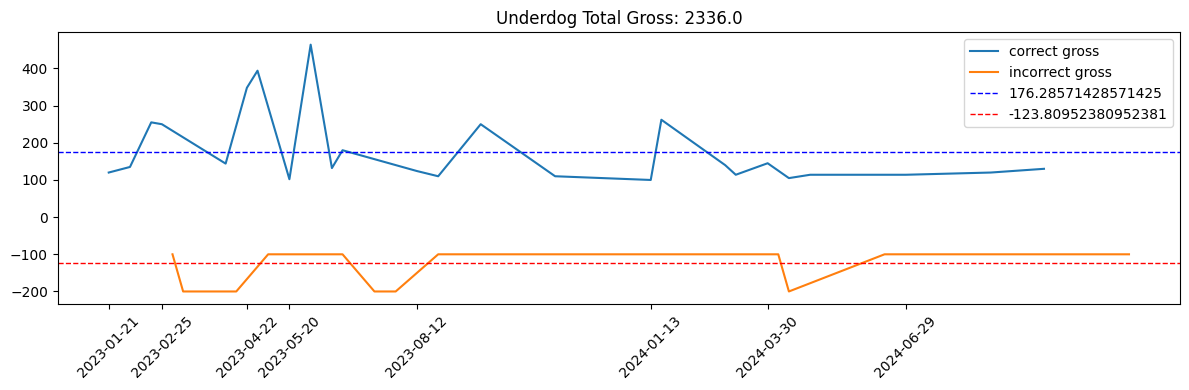

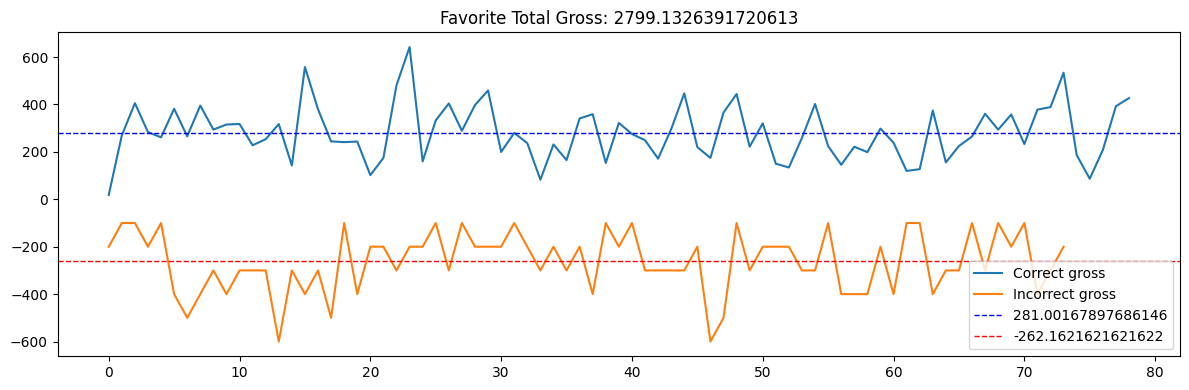

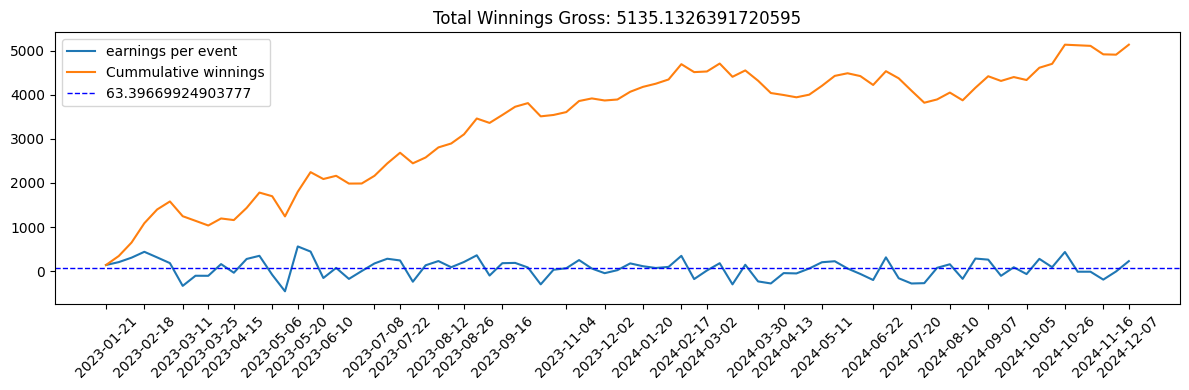

dog per bet: 36.5, fav per bet: 4.004481601104523


In [10]:
def expected_winnings(wager, odds, prob_w):
    ev = 0
    if odds > 0:
        ev = prob_w * ((odds/100) * wager) + (1-prob_w) * wager
    else: 
        ev = prob_w * ((100/odds) * wager) + (1-prob_w) * wager
    return ev

def winnings(wager, odds, win):
    gross = 0
    if win: 
        if odds > 0:
            gross = (odds/100) * wager
        else:
            gross = (100/-odds) * wager
    else:
        gross = -wager
    return gross 

def gross_winnings(df, wager):
    total_winnings = []
    for _,row in df.iterrows():
        line = row['winner_odds']
        win = None
        if row['correct_pred_winner'] == 1:
            win = True
        else:
            win = False
        gross = winnings(wager, line, win)
        total_winnings.append(gross)
    return total_winnings

wager = 100
df_correct_underdog['correct_underdog_winnings'] = gross_winnings(df_correct_underdog, wager)
df_incorrect_underdog['incorrect_underdog_loss'] = gross_winnings(df_incorrect_underdog, wager)
underdog_bet_gross = df_correct_underdog['correct_underdog_winnings'].sum() + df_incorrect_underdog['incorrect_underdog_loss'].sum()

correct_fav['correct_fav_winnings'] = gross_winnings(correct_fav,wager)
incorrect_fav['incorrect_fav_loss'] = gross_winnings(incorrect_fav, wager)
total_fav_gross = correct_fav['correct_fav_winnings'].sum() + incorrect_fav['incorrect_fav_loss'].sum()

df_results['total_winnings'] = gross_winnings(df_results, wager)
total_gross = sum(df_results['total_winnings'])

group_correct_dog = df_correct_underdog.groupby('Date')['correct_underdog_winnings'].sum()
group_incorrect_dog = df_incorrect_underdog.groupby('Date')['incorrect_underdog_loss'].sum()
plt.figure(figsize=(12,4))
plt.plot(group_correct_dog.index, group_correct_dog.values, label='correct gross')
plt.plot(group_incorrect_dog.index, group_incorrect_dog.values, label='incorrect gross')
plt.xticks(df_correct_underdog["Date"][::5], rotation=45)
plt.axhline(y=np.mean(group_correct_dog.values), color="blue", linestyle="--", linewidth=1, label=np.mean(group_correct_dog.values))
plt.axhline(y=np.mean(group_incorrect_dog.values), color="red", linestyle="--", linewidth=1, label=np.mean(group_incorrect_dog.values))
plt.title(f"Underdog Total Gross: {underdog_bet_gross}")
plt.legend()
plt.tight_layout()
plt.show()

group_correct_fav = correct_fav.groupby('Date')['correct_fav_winnings'].sum()
group_incorrect_fav = incorrect_fav.groupby('Date')['incorrect_fav_loss'].sum()
plt.figure(figsize=(12,4))
plt.plot(group_correct_fav.values, label="Correct gross")
plt.plot(group_incorrect_fav.values, label="Incorrect gross")
# plt.xticks(correct_fav["Date"][::15], rotation=45)
plt.axhline(y=np.mean(group_correct_fav.values), color="blue", linestyle="--", linewidth=1, label=np.mean(group_correct_fav.values))
plt.axhline(y=np.mean(group_incorrect_fav.values), color="red", linestyle="--", linewidth=1, label=np.mean(group_incorrect_fav.values))
plt.title(f'Favorite Total Gross: {total_fav_gross}')
plt.legend()
plt.tight_layout()
plt.show()

group_correct = df_results.groupby('Date')['total_winnings'].sum()
cum_winnings = np.cumsum(group_correct.values)
plt.figure(figsize=(12,4))
plt.plot(group_correct.index,group_correct.values, label='earnings per event')
plt.plot(group_correct.index, cum_winnings, label = 'Cummulative winnings')
plt.title(f'Total Winnings Gross: {total_gross}')
plt.xticks(df_results["Date"][::27], rotation=45)
plt.axhline(y=np.mean(group_correct.values), color="blue", linestyle="--", linewidth=1, label=np.mean(group_correct.values))
plt.legend()
plt.tight_layout()
plt.show()

dog_per_bet_gross = underdog_bet_gross / (len(df_correct_underdog)+len(df_incorrect_underdog))
fav_per_bet_gross = total_fav_gross / (len(correct_fav)+len(incorrect_fav))
print(f'dog per bet: {dog_per_bet_gross}, fav per bet: {fav_per_bet_gross}')


In [206]:
df_results['Date']

0      2023-01-21
1      2023-01-21
2      2023-02-04
3      2023-02-04
4      2023-02-04
          ...    
975    2024-12-07
976    2024-12-07
977    2024-12-07
978    2024-12-07
979    2024-12-07
Name: Date, Length: 763, dtype: object

C:\Users\jcmar\AppData\Local\Temp\ipykernel_13668\4276304867.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_results['f_star'] = df_results.groupby('Date').apply(lambda group: group.apply(kelly_criterion, axis=1)).reset_index(level=0, drop=True)
C:\Users\jcmar\AppData\Local\Temp\ipykernel_13668\4276304867.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_results.groupby('Date').apply(simulate_

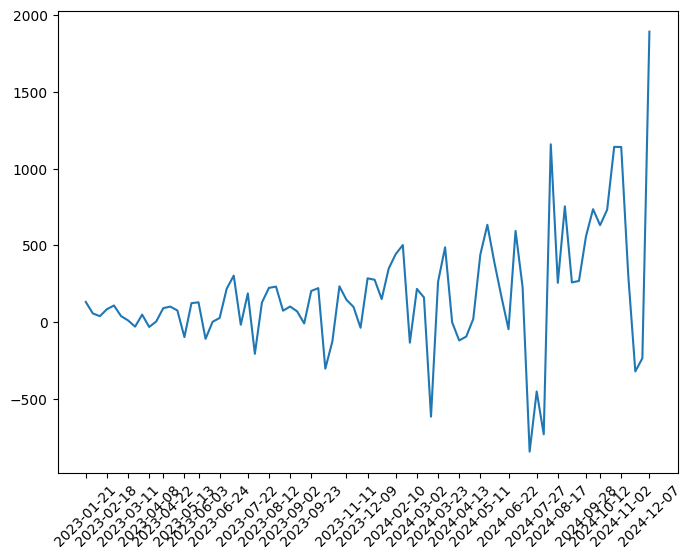

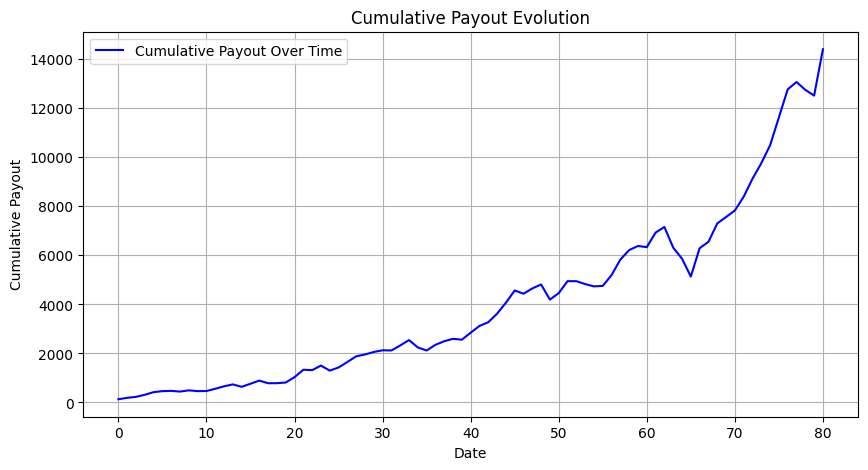

In [19]:
def kelly_criterion(row):
    p = row['prob_winner']
    odds=0
    if row['pred_winner'] == 1:
        line = row['RedOdds']
        if line > 0: 
            odds = line/100
        else:
            odds = 100/-line
    else:
        line = row['BlueOdds']
        if line > 0: 
            odds = line/100
        else:
            odds = 100/-line
    f_star = p - ((1-p)/odds)
    return f_star

df_results['f_star'] = df_results.groupby('Date').apply(lambda group: group.apply(kelly_criterion, axis=1)).reset_index(level=0, drop=True)
df_results['group_size'] = df_results[df_results['f_star'] > 0].groupby('Date')['Date'].transform('count')
df_results.fillna(1, inplace=True)
df_results['f_star'] = df_results['f_star'] / df_results['group_size']


initial_bankroll = 500
bankroll = initial_bankroll
bankroll_history = []  
wagers = []
single_payout = []
date_payout = defaultdict(list)

def simulate_betting(df):
    global bankroll, wagers, single_payout
    event_total = 0 
    date = df['Date'].iloc[0]
    for index, row in df.iterrows():
        
        bet_fraction = row['f_star'] 
        if bet_fraction < 0:
            payout = 0
            single_payout.append(payout)
            wagers.append(payout)
            continue  

        bet_size = bankroll * bet_fraction  
        wagers.append(bet_size)
        odds=0
        if row['pred_winner'] == row['Winner']:  
            if row['pred_winner'] == 1:
                odds = row['RedOdds']
            else:
                odds = row['BlueOdds']

            if odds > 0:
                payout = bet_size * (odds / 100)
                single_payout.append(payout)
            else:
                payout = bet_size * (100 / -odds)
                single_payout.append(payout)

            event_total += payout  
        else:
            payout = 0
            event_total -= bet_size 
            single_payout.append(-bet_size) 

    # date_payout[date] = event_total
    bankroll_history.append(bankroll + event_total)
    bankroll = bankroll_history[-1]  

df_results.groupby('Date').apply(simulate_betting)
df_results['wager'] = wagers
df_results['single_payout'] = single_payout
df_results['event_payout'] = df_results.groupby('Date')['single_payout'].transform('sum')
# df_results['Payout'] = df_results['Date'].map(date_payout)
plt.figure(figsize=(8,6))
plt.plot(df_results['Date'], df_results['event_payout'])
plt.xticks(df_results["Date"][::30], rotation=45)
plt.show()


daily_payouts = df_results.groupby('Date')['event_payout'].first()  # Gets one value per date
cumulative_payouts = daily_payouts.cumsum()
payout_arr = np.array(cumulative_payouts.values)
plt.figure(figsize=(10,5))
plt.plot(payout_arr , label="Cumulative Payout Over Time", color="blue")

plt.xlabel("Date")
plt.ylabel("Cumulative Payout")
plt.title("Cumulative Payout Evolution")
plt.legend()
# plt.xticks(cumulative_payouts.index[::15], rotation=45)  # Show every 30th date for readability
plt.grid()

In [20]:
df_results[['f_star','Date','pred_winner' , 'Winner',"RedOdds",'BlueOdds','f_star','wager','single_payout','event_payout','RedFighter','BlueFighter','prob_winner','group_size']].tail(15)

,f_star,Date,pred_winner,Winner,RedOdds,BlueOdds,f_star,wager,single_payout,event_payout,RedFighter,BlueFighter,prob_winner,group_size
965,0.010578,2024-11-23,0.0,0.0,190.0,-230.0,0.010578,140.192667,60.953333,-234.615553,Baergeng Jieleyisi,SuYoung You,0.722613,8.0
966,0.091128,2024-12-07,1.0,1.0,-210.0,295.0,0.091128,1186.354312,564.930625,1891.169700,Shavkat Rakhmonov,Ian Machado Garry,0.853796,6.0
967,-0.387541,2024-12-07,1.0,1.0,-380.0,300.0,-0.387541,0.000000,0.000000,1891.169700,Ciryl Gane,Alexander Volkov,0.710929,1.0
968,-0.759566,2024-12-07,1.0,1.0,-950.0,625.0,-0.759566,0.000000,0.000000,1891.169700,Bryce Mitchell,Kron Gracie,0.832422,1.0
969,-0.105326,2024-12-07,1.0,0.0,-130.0,110.0,-0.105326,0.000000,0.000000,1891.169700,Nate Landwehr,Dooho Choi,0.519424,1.0
970,-0.129989,2024-12-07,1.0,1.0,-380.0,300.0,-0.129989,0.000000,0.000000,1891.169700,Dominick Reyes,Anthony Smith,0.764586,1.0
971,-1.803062,2024-12-07,1.0,1.0,-650.0,-162.0,-1.803062,0.000000,0.000000,1891.169700,Vicente Luque,Themba Gorimbo,0.626258,1.0
972,0.015465,2024-12-07,1.0,0.0,-112.0,-108.0,0.015465,201.326123,-201.326123,1891.169700,Chris Weidman,Eryk Anders,0.572069,6.0
973,0.044725,2024-12-07,0.0,0.0,150.0,-180.0,0.044725,582.251949,323.473305,1891.169700,Randy Brown,Bryan Battle,0.738696,6.0
974,-0.321441,2024-12-07,0.0,0.0,142.0,-170.0,-0.321441,0.000000,0.000000,1891.169700,Cody Durden,Joshua Van,0.510577,1.0


In [21]:
df_results["Date"].head()

0    2023-01-21
1    2023-01-21
2    2023-02-04
3    2023-02-04
4    2023-02-04
Name: Date, dtype: object

In [195]:
p = .855136
q = (100/210)
(p - ((1-p)/q)) / 14

0.03935154285714286

In [70]:
df_results.to_csv(r'C:\Users\jcmar\Documents\ufc_results.csv', index=False)
